# Natural Language Processing for Disaster Tweet Classification

**Project Overview**  
This notebook implements a machine learning pipeline to classify tweets as either describing a real disaster or not. The project utilizes traditional NLP techniques, including TF-IDF feature extraction and comparative modeling using Naive Bayes, Logistic Regression, and Linear Support Vector Machines (SVM). 

**Evaluation Metric**  
The primary metric for this task is the F1-Score, which provides a balanced measure of Precision and Recall, crucial for imbalanced classification tasks where false alarms and missed detections carry different costs.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, ConfusionMatrixDisplay

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load datasets
train_path = '/kaggle/input/datasets/riadhhossain/disaster-tweets/train (1).csv'
test_path = '/kaggle/input/datasets/riadhhossain/disaster-tweets/test (1).csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Training Set Shape: {train_df.shape}")
print(f"Test Set Shape: {test_df.shape}\n")

print("=== Target Distribution ===")
print(train_df['target'].value_counts(normalize=True).map('{:.1%}'.format))

Training Set Shape: (7613, 5)
Test Set Shape: (3263, 4)

=== Target Distribution ===
target
0    57.0%
1    43.0%
Name: proportion, dtype: object


# Exploratory Data Analysis (EDA)

/tmp/ipykernel_16/2336543882.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Not Disaster', 'Real Disaster'])


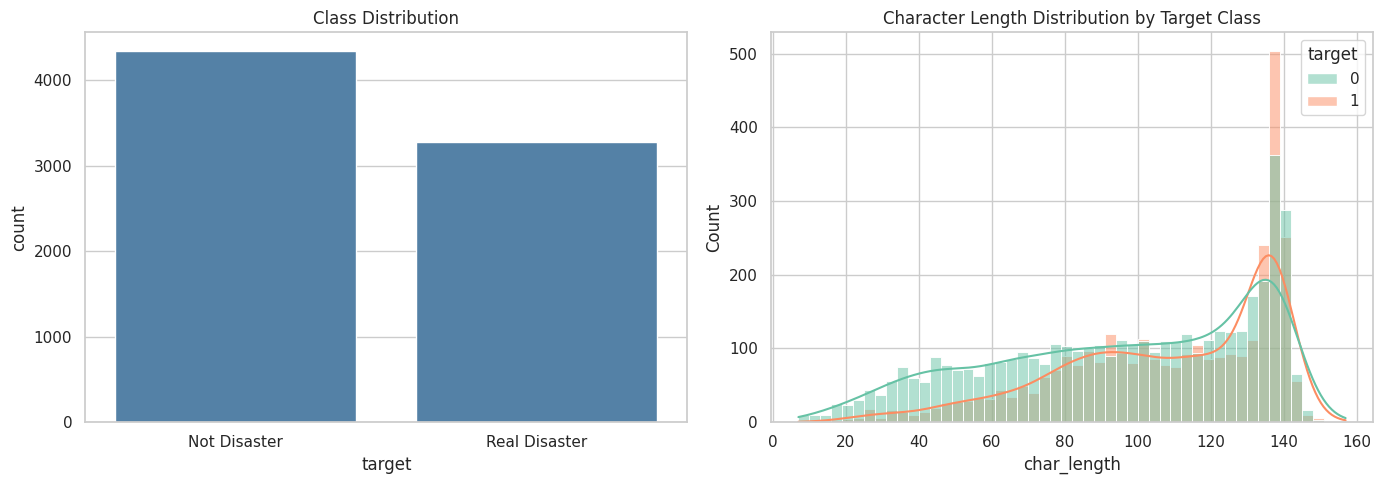

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class Distribution
sns.countplot(x='target', data=train_df, ax=axes[0], color='steelblue')
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Not Disaster', 'Real Disaster'])

# Text Length Distribution
train_df['char_length'] = train_df['text'].str.len()
sns.histplot(data=train_df, x='char_length', hue='target', kde=True, ax=axes[1], palette='Set2', bins=50)
axes[1].set_title('Character Length Distribution by Target Class')

plt.tight_layout()
plt.show()

## Text Preprocessing


In [4]:
def clean_text(text):
    """Cleans tweet text by removing URLs, mentions, and normalizing whitespace."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply preprocessing
train_df['cleaned_text'] = train_df['text'].apply(clean_text)
test_df['cleaned_text'] = test_df['text'].apply(clean_text)

print("=== Preprocessing Example ===")
print(f"Original: {train_df['text'].iloc[0]}")
print(f"Cleaned:  {train_df['cleaned_text'].iloc[0]}")

=== Preprocessing Example ===
Original: Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
Cleaned:  our deeds are the reason of this #earthquake may allah forgive us all


# Train/Validation Split

In [5]:
X = train_df['cleaned_text']
y = train_df['target']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Training samples: 6090
Validation samples: 1523


# Feature Extraction (TF-IDF)

In [6]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True, 
    ngram_range=(1, 2), 
    min_df=2, 
    max_df=0.95, 
    sublinear_tf=True
)

# Fit ONLY on training data to prevent data leakage
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)} features")

Vocabulary size: 14087 features


#  Model Training and Evaluation

In [7]:
models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Linear SVM': LinearSVC(random_state=RANDOM_STATE, max_iter=2000)
}

results = []

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - start_time
    
    y_pred = model.predict(X_val_tfidf)
    f1 = f1_score(y_val, y_pred)
    acc = accuracy_score(y_val, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'F1 Score': round(f1, 4),
        'Training Time (s)': round(train_time, 4)
    })
    print(f"{name} -> F1: {f1:.4f} | Accuracy: {acc:.4f}")

results_df = pd.DataFrame(results)
display(results_df.style.highlight_max(subset=['F1 Score'], color='lightgreen'))

Multinomial Naive Bayes -> F1: 0.7535 | Accuracy: 0.8175
Logistic Regression -> F1: 0.7691 | Accuracy: 0.8175
Linear SVM -> F1: 0.7737 | Accuracy: 0.8102


,Model,Accuracy,F1 Score,Training Time (s)
0,Multinomial Naive Bayes,0.817500,0.753500,0.007300
1,Logistic Regression,0.817500,0.769100,1.185800
2,Linear SVM,0.810200,0.773700,0.092800


# Confusion Matrix and Feature

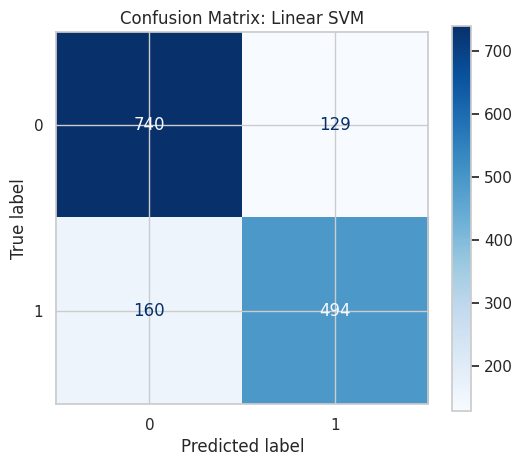

Top 10 Disaster Indicators:
          feature  coefficient
5514    hiroshima     2.470441
4362        fires     2.022071
13497    wildfire     1.960230
11048       storm     1.947757
4444       floods     1.897084
3694   earthquake     1.756266
12528       train     1.751044
8019         near     1.679816
12467     tornado     1.678710
2001    buildings     1.632691


In [8]:
# Confusion Matrix for Linear SVM
svm_model = LinearSVC(random_state=RANDOM_STATE, max_iter=2000)
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_val_tfidf)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(svm_model, X_val_tfidf, y_val, ax=ax, cmap='Blues')
plt.title('Confusion Matrix: Linear SVM')
plt.show()

# Feature Importance
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = svm_model.coef_[0]
feature_importance = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})

print("Top 10 Disaster Indicators:")
print(feature_importance.sort_values('coefficient', ascending=False).head(10))

# Error Analysis

In [9]:
error_df = pd.DataFrame({
    'text': X_val.reset_index(drop=True),
    'actual': y_val.reset_index(drop=True),
    'predicted': y_pred_svm
})

print("=== Sample False Positives (Predicted Disaster, Actually Not) ===")
fps = error_df[(error_df['actual'] == 0) & (error_df['predicted'] == 1)].sample(3, random_state=RANDOM_STATE)
for idx, row in fps.iterrows():
    print(f"- \"{row['text']}\"")

print("\n=== Sample False Negatives (Predicted Not Disaster, Actually Real) ===")
fns = error_df[(error_df['actual'] == 1) & (error_df['predicted'] == 0)].sample(3, random_state=RANDOM_STATE)
for idx, row in fns.iterrows():
    print(f"- \"{row['text']}\"")

=== Sample False Positives (Predicted Disaster, Actually Not) ===
- "go to sleep before someone screams at us??????"
- "+ catastrophe! it caused people to get reckless and the bottom line is that at least three of your friends will have +"
- "3 bedrooms 1 baths for sale in 29 palms ca. ( (youtube video:..."

=== Sample False Negatives (Predicted Not Disaster, Actually Real) ===
- "that looks so desolate and just...depressing"
- "unpredictable disconnected and social casualty are my favorites how do people not like them"
- "senators calling for emergency housing: boxer feinstein back plan to move #homeless vets to va campus"


# Predictions and Submission

In [10]:
# Retrain on full training data
X_full = train_df['cleaned_text']
y_full = train_df['target']

final_vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)
X_full_tfidf = final_vectorizer.fit_transform(X_full)

final_model = LinearSVC(random_state=RANDOM_STATE, max_iter=2000)
final_model.fit(X_full_tfidf, y_full)

# Predict on test set
X_test_tfidf = final_vectorizer.transform(test_df['cleaned_text'])
test_predictions = final_model.predict(X_test_tfidf)

# Create submission file
submission_df = pd.DataFrame({'id': test_df['id'], 'target': test_predictions})
os.makedirs('outputs', exist_ok=True)
submission_df.to_csv('outputs/submission_test.csv', index=False)

print("Submission file saved to 'outputs/submission_test.csv'")
display(submission_df.head())

Submission file saved to 'outputs/submission_test.csv'


,id,target
0,0,1
1,2,1
2,3,1
3,9,0
4,11,1


## Advanced NLP: Contextual Classification with DistilBERT (Transformer Model)

Traditional models like TF-IDF + SVM treat words as independent tokens, making them vulnerable to metaphorical language and sarcasm. **BERT (Bidirectional Encoder Representations from Transformers)** solves this by generating context-aware embeddings, where the meaning of each word is influenced by all surrounding words in the sentence.

For computational efficiency, we use **DistilBERT**, which retains 97% of BERT's language understanding while being 40% smaller and 60% faster. This makes it suitable for Kaggle's free GPU environment.

The model will be fine-tuned on our training data using the Hugging Face `Trainer` API, evaluated using the **F1-Score** (Kaggle's official metric), and used to generate predictions for the test set.

In [11]:

!pip install -q transformers datasets evaluate accelerate

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
import evaluate
import numpy as np
import pandas as pd

# Verify GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.3 MB/s eta 0:00:00
Using device: cpu


# Prepare Data for BERT

In [12]:
# We already have train_df and test_df loaded from earlier cells.
# Use the original 'text' column — BERT's tokenizer handles its own preprocessing.

# 1. Create a stratified train/validation split (same as before, no data leakage)
bert_train_df, bert_val_df = train_test_split(
    train_df[['text', 'target']], 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=train_df['target']
)

# 2. CRITICAL FIX: Rename 'target' to 'labels' 
# Hugging Face Trainer strictly requires the target column to be named 'labels'
bert_train_df = bert_train_df.rename(columns={'target': 'labels'})
bert_val_df = bert_val_df.rename(columns={'target': 'labels'})

# 3. Convert Pandas DataFrames to Hugging Face Dataset objects
train_dataset = Dataset.from_pandas(bert_train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(bert_val_df.reset_index(drop=True))

print(f"BERT Training samples: {len(train_dataset)}")
print(f"BERT Validation samples: {len(val_dataset)}")

BERT Training samples: 6090
BERT Validation samples: 1523


# Tokenization

In [13]:
# Load the DistilBERT tokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    """
    Tokenizes text into input IDs and attention masks.
    max_length=128 is sufficient for tweets (max 280 characters).
    truncation=True ensures no sequence exceeds the model's limit.
    """
    return tokenizer(
        examples["text"], 
        padding="max_length", 
        truncation=True, 
        max_length=128
    )

# Apply tokenization to both datasets
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

print("Tokenization complete.")
print(f"Sample input_ids length: {len(tokenized_train[0]['input_ids'])}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/6090 [00:00<?, ? examples/s]

Map:   0%|          | 0/1523 [00:00<?, ? examples/s]

Tokenization complete.
Sample input_ids length: 128


# F1 Metric

In [14]:
# Load the F1 metric from Hugging Face evaluate library
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    """
    Computes F1-Score for model evaluation.
    Kaggle evaluates submissions using F1, so this is our primary metric.
    """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return f1_metric.compute(predictions=predictions, references=labels, average="binary")

# Initialize BERT Model

In [15]:
# Load pre-trained DistilBERT with a binary classification head
# num_labels=2 because we have two classes: 0 (Not Disaster) and 1 (Real Disaster)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=2
)

print(f"Model loaded: {model_name}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilbert-base-uncased
Total parameters: 66,955,010


# Training Arguments

In [16]:
training_args = TrainingArguments(
    output_dir="./bert_results",
    eval_strategy="epoch",  # FIXED: Changed from 'evaluation_strategy' to 'eval_strategy'
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none",
    fp16=True if device.type == 'cuda' else False,  # Only enable on GPU
)

print("Training arguments configured successfully.")

Training arguments configured successfully.


# Train BERT

In [17]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

# Start training
print("Beginning BERT fine-tuning...")
trainer.train()
print("Training complete.")

Beginning BERT fine-tuning...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,F1
1,0.455614,0.370804,0.816026
2,0.340275,0.417874,0.811094
3,0.240824,0.425490,0.807752


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training complete.


# Evaluate BERT & Generate Submission File

In [18]:
from sklearn.metrics import classification_report, accuracy_score

# Evaluate BERT
eval_results = trainer.evaluate()
print(f"DistilBERT Validation F1 Score: {eval_results['eval_f1']:.4f}")

# Generate predictions on the test set
test_dataset = Dataset.from_pandas(test_df[['id', 'text']].reset_index(drop=True))
tokenized_test = test_dataset.map(tokenize_function, batched=True)

predictions_output = trainer.predict(tokenized_test)
test_preds = np.argmax(predictions_output.predictions, axis=-1)

# Create submission DataFrame
submission_df = pd.DataFrame({'id': test_df['id'], 'target': test_preds})
submission_df.to_csv('submission_bert.csv', index=False)

print("\nSubmission file saved as 'submission_bert.csv'")
display(submission_df.head())

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


DistilBERT Validation F1 Score: 0.8160


Map:   0%|          | 0/3263 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Submission file saved as 'submission_bert.csv'


,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1


# SAVE Model for Deployment

In [19]:
import os
import zipfile
import joblib


bert_save_dir = "/kaggle/working/final_bert_model"
model.save_pretrained(bert_save_dir)
tokenizer.save_pretrained(bert_save_dir)
print(f"✅ DistilBERT model saved to: {bert_save_dir}")

# BERT model into a ZIP file 
bert_zip_path = "/kaggle/working/final_bert_model.zip"
with zipfile.ZipFile(bert_zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(bert_save_dir):
        for file in files:
            file_path = os.path.join(root, file)
            # Create relative path for the zip archive
            arcname = os.path.relpath(file_path, "/kaggle/working/")
            zipf.write(file_path, arcname)
print(f"✅ DistilBERT packaged into: {bert_zip_path}")

# 2. SAVE TRADITIONAL ML MODEL (TF-IDF + SVM)
joblib.dump(final_vectorizer, "/kaggle/working/tfidf_vectorizer.pkl")
joblib.dump(final_model, "/kaggle/working/linear_svm_model.pkl")
print("✅ TF-IDF Vectorizer and Linear SVM model saved to Output.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ DistilBERT model saved to: /kaggle/working/final_bert_model
✅ DistilBERT packaged into: /kaggle/working/final_bert_model.zip
✅ TF-IDF Vectorizer and Linear SVM model saved to Output.
